# Regression

An analysis of the <span style ="color: #EB6800;">Astoria-Ditmars Blvd (N,W)</span> subway station with a multiple linear regression	

### Load ins 

In [113]:
setwd("/Users/Local/statsproject")

In [114]:
list.files()

[1] "data"       "notebooks"  "pics"       "README.md"  "references"
[6] "src"

In [115]:
source("src/functions_and_things.r")

load_libraries()

nyc_blue   = "#0062CF"
nyc_orange = "#EB6800"

In [116]:
df <- read.csv("data/clean/queens.csv")

In [127]:
dim(df)

[1] 557   8

In [117]:
colSums(is.na(df))

X      date ridership  min_temp      snow      rain 
        0         0         0       191       192       191

In [118]:
df |> 
    mutate(date = as.Date(date),
           day  = weekdays(date),
           weekend = ifelse(day == "Saturday" | day == "Sunday", 1, 0),
           weekend = as.factor(weekend),
           weekend = factor(weekend, labels = c("Weekday", "Weekend")),
           rain    = replace_na(rain, 0),
           rain_d  = rain > 0,
           temp    = as.numeric(min_temp),
           snow    = as.numeric(snow)) |>
    select(-X, -min_temp) -> df

head(df)

,date,ridership,snow,rain,day,weekend,rain_d,temp
,<date>,<int>,<dbl>,<dbl>,<chr>,<fct>,<lgl>,<dbl>
1,2024-06-01,1414,0,0.00,Saturday,Weekend,FALSE,62
2,2024-06-02,1068,0,0.00,Sunday,Weekend,FALSE,62
3,2024-06-03,2337,0,0.02,Monday,Weekday,TRUE,66
4,2024-06-04,2674,0,0.00,Tuesday,Weekday,FALSE,64
5,2024-06-05,2545,0,0.04,Wednesday,Weekday,TRUE,63
6,2024-06-06,2407,0,0.58,Thursday,Weekday,TRUE,69


### Some plots

In [119]:
summary(df)

      date              ridership         snow              rain        
 Min.   :2024-06-01   Min.   :   2   Min.   :0.00000   Min.   :0.00000  
 1st Qu.:2024-10-18   1st Qu.:1314   1st Qu.:0.00000   1st Qu.:0.00000  
 Median :2025-03-06   Median :2592   Median :0.00000   Median :0.00000  
 Mean   :2025-03-06   Mean   :2291   Mean   :0.05644   Mean   :0.05871  
 3rd Qu.:2025-07-23   3rd Qu.:3108   3rd Qu.:0.00000   3rd Qu.:0.00000  
 Max.   :2025-12-10   Max.   :3616   Max.   :3.10000   Max.   :1.49000  
                                     NA's   :192                        
     day               weekend      rain_d             temp      
 Length:557         Weekday:398   Mode :logical   Min.   :12.00  
 Class :character   Weekend:159   FALSE:435       1st Qu.:38.00  
 Mode  :character                 TRUE :122       Median :50.00  
                                                  Mean   :49.49  
                                                  3rd Qu.:63.00  
                    

Warning message:
“Removed 191 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 192 rows containing non-finite outside the scale range (`stat_bin()`).”


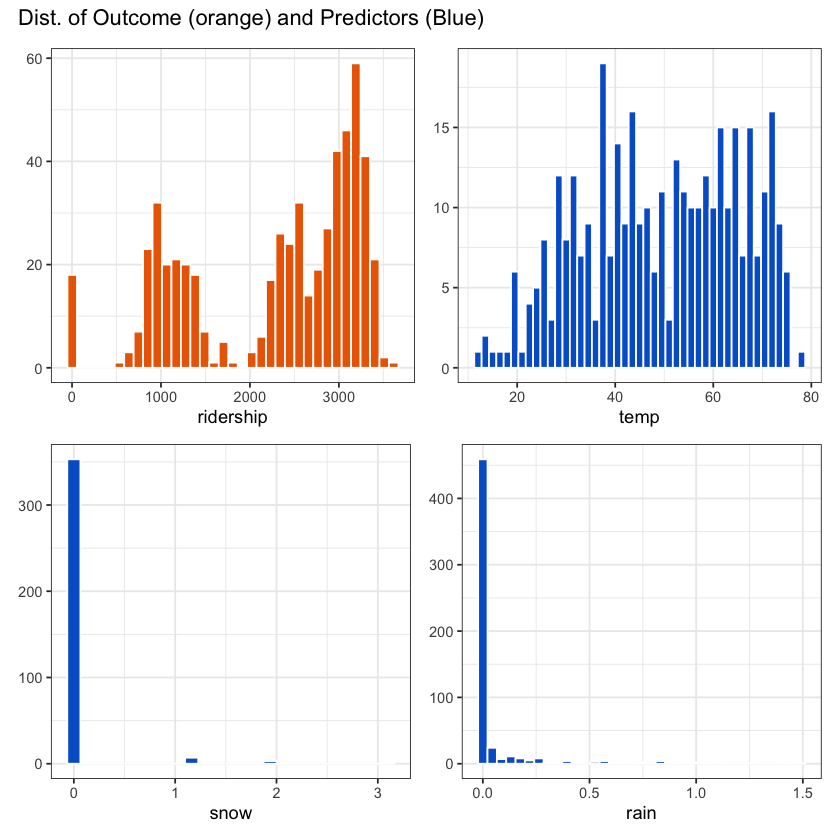

In [120]:
t <- theme_bw() + theme(axis.title.y = element_blank())
a <- ggplot(data = df, aes(x = ridership)) + 
        geom_histogram(bins = 35, color = "white", fill = nyc_orange) + t

b <- ggplot(data = df, aes(x = temp)) + 
        geom_histogram(bins = 45, color = "white", fill = nyc_blue) + t

c <- ggplot(data = df, aes(x = snow)) + 
        geom_histogram(bins = 25, color = "white", fill = nyc_blue) + t

d <- ggplot(data = df, aes(x = rain)) + 
        geom_histogram(bins = 35, color = "white", fill = nyc_blue) + t

(a + b )/ (c + d) + plot_annotation(title = "Dist. of Outcome (orange) and Predictors (Blue)")

In [121]:
df[which.min(df$ridership), ]

,date,ridership,snow,rain,day,weekend,rain_d,temp
,<date>,<int>,<dbl>,<dbl>,<chr>,<fct>,<lgl>,<dbl>
421,2025-07-26,2,NA,0,Saturday,Weekend,FALSE,NA


In [122]:
df |> mutate(roll = rollmean(ridership, k= 7, fill = NA)) -> smooth

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 6 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 6 rows containing missing values or values outside the scale range
(`geom_line()`).”


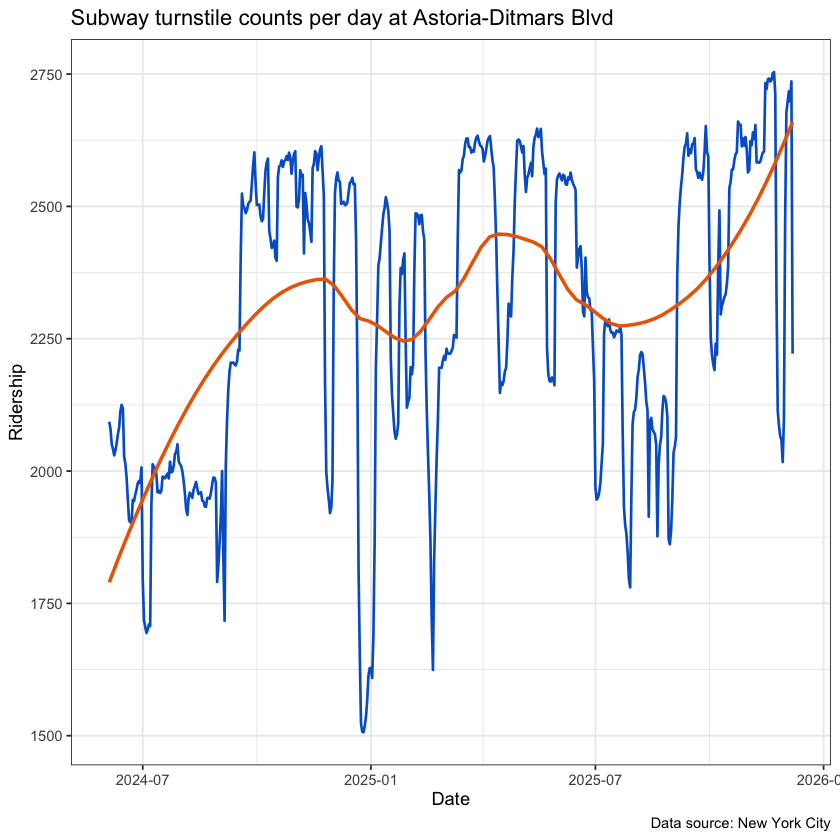

In [123]:
# ref 2 loess 

ggplot(data = smooth, aes(x = date, y = roll)) + 
    geom_line(col = nyc_blue, lwd = .75) + theme_bw() +
    geom_smooth(col = nyc_orange, method = "loess", span = .6, se=FALSE) + 
    labs(title = "Subway turnstile counts per day at Astoria-Ditmars Blvd",
         x     = "Date",
         y     = "Ridership",
         caption = "Data source: New York City")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 191 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 191 rows containing missing values or values outside the scale range
(`geom_point()`).”


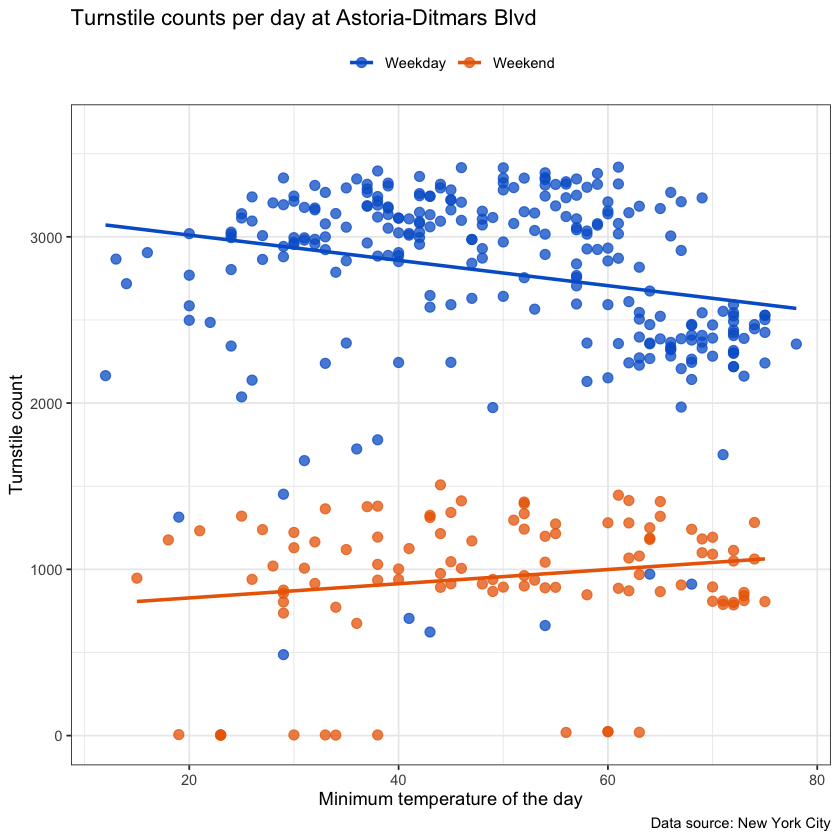

In [124]:
ggplot(data = df, aes(x = temp, y = ridership, color = weekend)) + 
    geom_point(size = 2.5, alpha = .75) + theme_bw() + 
    theme(legend.position = "top", legend.title = element_blank()) + 
    scale_color_manual(values = c("Weekend" = nyc_orange, "Weekday" = nyc_blue)) +
    geom_smooth(method = "lm", se = FALSE) + 
    labs(title = "Turnstile counts per day at Astoria-Ditmars Blvd",
         x     = "Minimum temperature of the day",
         y     = "Turnstile count",
         caption = "Data source: New York City")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 435 rows containing non-finite outside the scale range
(`stat_smooth()`).”


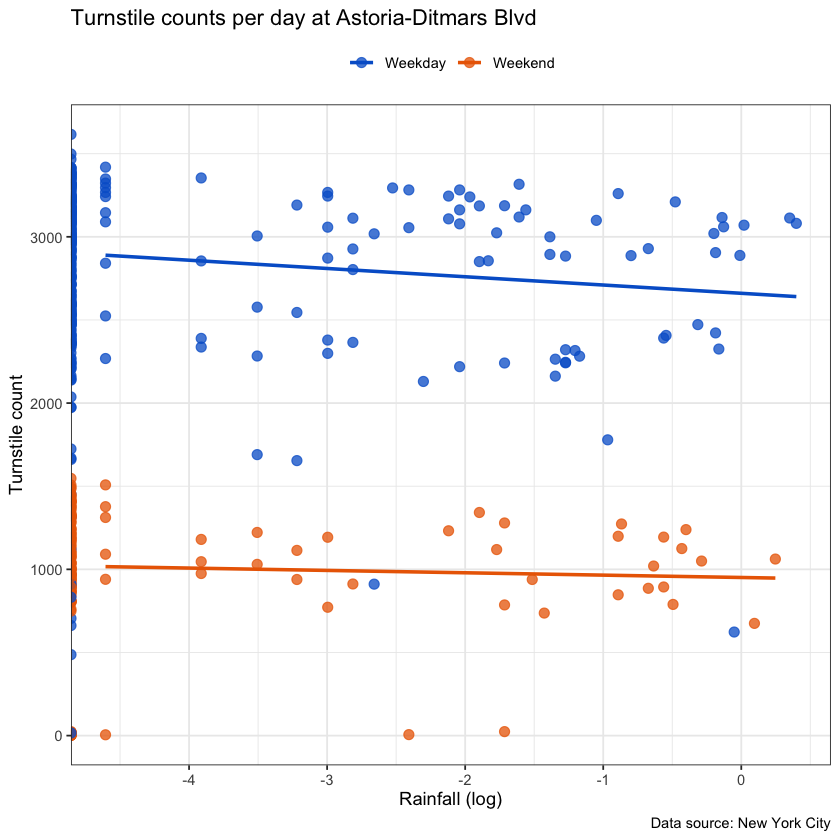

In [125]:
ggplot(data = df, aes(x = log(rain), y = ridership, color = weekend)) + 
    geom_point(size = 2.5, alpha = .75) + theme_bw() + 
    theme(legend.position = "top", legend.title = element_blank()) + 
    scale_color_manual(values = c("Weekend" = nyc_orange, "Weekday" = nyc_blue)) +
    geom_smooth(method = "lm", se = FALSE) + 
    labs(title = "Turnstile counts per day at Astoria-Ditmars Blvd",
         x     = "Rainfall (log)",
         y     = "Turnstile count",
         caption = "Data source: New York City")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 192 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 192 rows containing missing values or values outside the scale range
(`geom_point()`).”


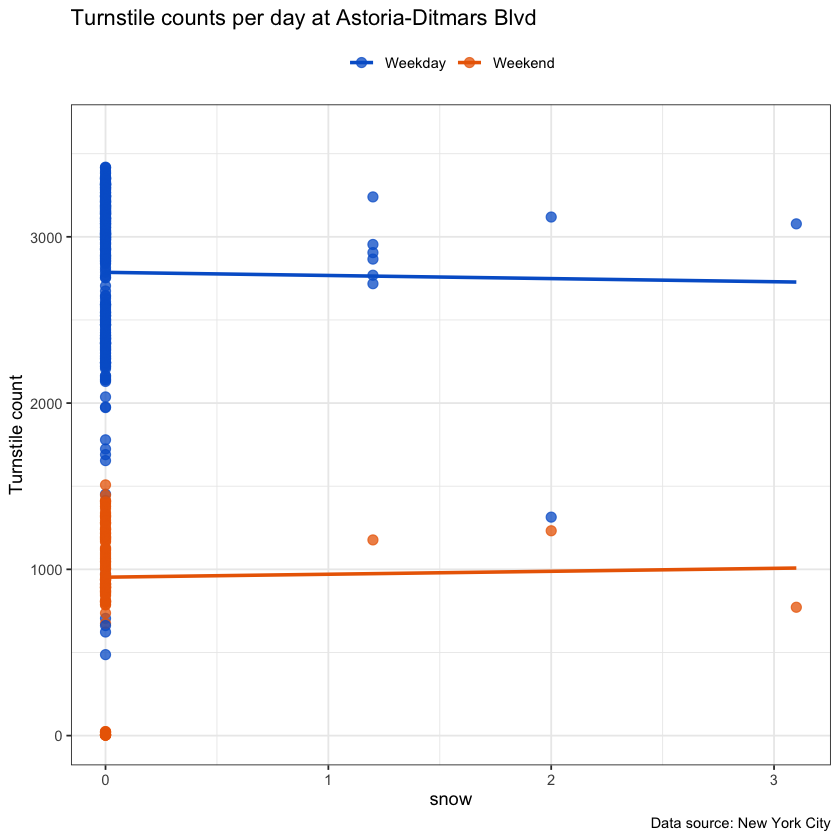

In [126]:
ggplot(data = df, aes(x = snow, y = ridership, color = weekend)) + 
    geom_point(size = 2.5, alpha = .75) + theme_bw() + 
    theme(legend.position = "top", legend.title = element_blank()) + 
    scale_color_manual(values = c("Weekend" = nyc_orange, "Weekday" = nyc_blue)) +
    geom_smooth(method = "lm", se = FALSE) + 
    labs(title = "Turnstile counts per day at Astoria-Ditmars Blvd",
         x     = "snow",
         y     = "Turnstile count",
         caption = "Data source: New York City")

### Regression

### Diagnostics

### Evaluation